#### Finding the time distributions between each node

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with open('slurm_job_data.csv', 'r') as f:
    dataframe = pd.read_csv(f, delimiter='|')

dataframe = dataframe.iloc[::3].reset_index(drop=True)
dataframe['Elapsed'] = pd.to_timedelta(dataframe['Elapsed']).dt.total_seconds() / 3600

print(dataframe['Elapsed'])

0      2.518333
1      3.122222
2      2.630278
3      3.308056
4      2.648889
         ...   
253    2.799722
254    2.932778
255    2.946111
256    2.961389
257    2.962222
Name: Elapsed, Length: 258, dtype: float64


In [3]:
# print(dataframe['NodeList'])

node_elapsed_dict = dataframe.groupby('NodeList')['Elapsed'].apply(list).to_dict()
print(node_elapsed_dict)

nodes = list(node_elapsed_dict.keys())

{'u001': [3.7919444444444443, 3.7175, 3.871111111111111, 3.9319444444444445], 'u009': [4.088055555555556], 'u010': [7.265, 7.354722222222223, 4.288333333333333, 4.315555555555555, 4.305555555555555, 4.304722222222222, 4.247222222222222, 4.237777777777778, 4.309444444444445], 'u011': [4.151944444444444], 'u029': [3.838611111111111, 3.7819444444444446, 4.333333333333333, 4.35], 'u032': [3.5319444444444446, 3.483611111111111, 3.492777777777778, 3.4891666666666667], 'u033': [3.5991666666666666, 3.5508333333333333, 3.5233333333333334, 3.4744444444444444], 'u034': [3.7266666666666666, 3.5908333333333333], 'u038': [3.566388888888889, 3.406388888888889, 3.7383333333333333, 3.7358333333333333, 4.476666666666667, 4.253333333333333], 'u040': [3.5505555555555555, 3.7075, 6.112777777777778, 3.685, 4.141388888888889, 3.5905555555555555], 'u068': [3.9358333333333335], 'u069': [4.243333333333333, 4.24, 4.045833333333333, 4.883611111111111], 'u071': [4.16, 3.658333333333333, 3.6661111111111113, 3.59416

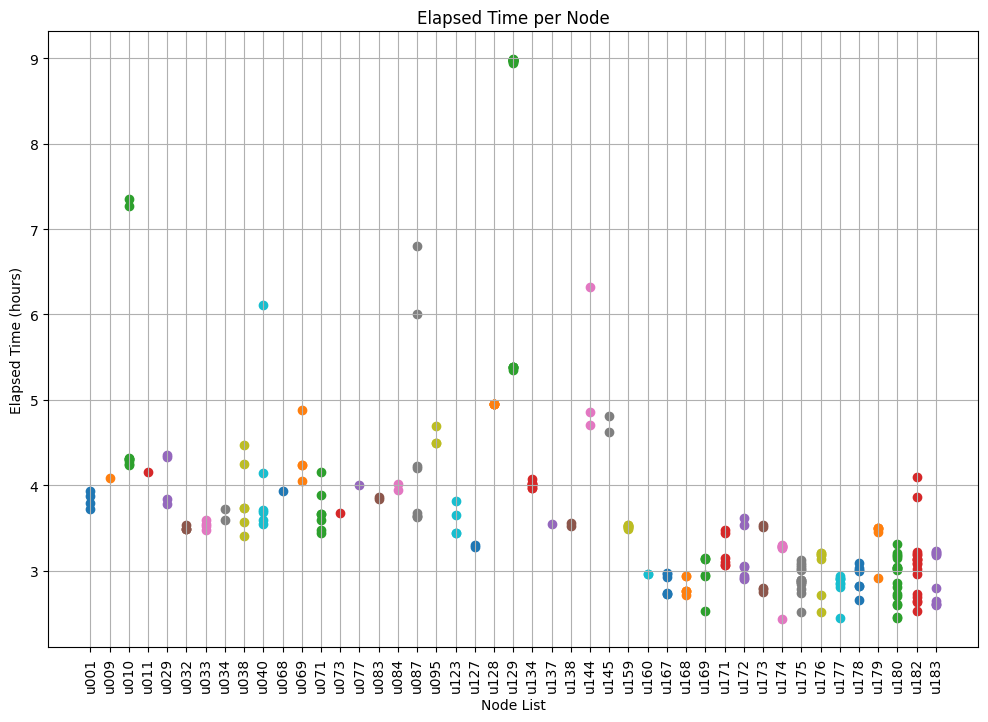

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot()
ax.grid(True)

x_numerical = np.arange(len(nodes))

for i, durations in enumerate(node_elapsed_dict.values()):
    durations = np.array(durations)
    ax.scatter(x_numerical[i] * np.ones(len(durations)), durations)

ax.set_xticks(x_numerical)
ax.set_xticklabels(nodes, rotation=90)
ax.set_xlabel('Node List')
ax.set_ylabel('Elapsed Time (hours)')
ax.set_title('Elapsed Time per Node')

# fig.savefig('Node Timing.png', dpi=300)

plt.show()